## División del corups por párrafos

### Librerías

In [3]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from umap import UMAP


from sentence_transformers import CrossEncoder
from scipy.special import expit


import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler

nltk.download("punkt")
nltk.download('stopwords')
nlp = spacy.load("es_core_news_sm")
stop = stopwords.words('spanish')

[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Funciones principales

In [4]:


def cargar_datos(noticias, n_noticia=0, print_info=False):
    """
    Carga título y contenido de una noticia
    input: n_noticia (int): índice de noticia
    output: titulo, fragmentos_contenido (list)
    """
    noticia = noticias[n_noticia]
    titulo = noticia["Título"]
    contenido = noticia["Contenido"]
    fragmentos_contenido = sent_tokenize(contenido, language='spanish')
    
    if print_info:
        print(f"Título: {titulo}\n")
        print(f"\nFragmentos:")
        for i, frag in enumerate(fragmentos_contenido, 1):
            print(f"  Fragmento {i}: {frag}")
    
    return titulo, fragmentos_contenido,noticia


def extraer_features_linguisticos(corpus):
    """
    Extrae features de: deícticos, puntuación, superlativos
    input: corpus (list): lista de textos
    output: array de shape (len(corpus), 3)
    """
    deicticos = {'yo', 'tú', 'él', 'ella', 'nosotros', 'vosotros', 'ellos', 'ellas', 
                 'me', 'te', 'le', 'nos', 'os', 'les', 'mi', 'tu', 'su', 'nuestro', 'vuestro'}
    
    superlativos = {'muy', 'extremadamente', 'increíblemente', 'absolutamente', 
                   'totalmente', 'completamente', 'realmente', 'verdaderamente'}
    
    features = []
    
    for texto in corpus:
        texto_lower = texto.lower()
        palabras = word_tokenize(texto_lower, language='spanish')
        
        deicticos_count = sum(1 for p in palabras if p in deicticos)
        puntuacion_count = len(re.findall(r'[!?¡¿;:]', texto))
        superlativos_count = sum(1 for p in palabras if p in superlativos or 
                                any(sup in p for sup in ['ísimo', 'ísima', 'ísimos', 'ísimas']))
        
        features.append([deicticos_count, puntuacion_count, superlativos_count])
    
    return np.array(features)


def calcular_diferencia_features(corpus):
    """
    Calcula diferencia de features entre título y fragmentos
    input: corpus (list): lista de textos
    output: diferencias (array), features normalizados (tuple)
    """
    
    features = extraer_features_linguisticos(corpus)
    
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)
    
    titulo_norm = features_norm[0]
    fragmentos_norm = features_norm[1:]
    
    diferencias = np.linalg.norm(fragmentos_norm - titulo_norm, axis=1)
    
    return diferencias, (titulo_norm, fragmentos_norm)


# =========================
# LSA (reducción a 2D)
# =========================

def LSA_vectors(corpus,min_df=1,plot=False):
    tfidf_vectorizer = TfidfVectorizer(min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(corpus)


    n_components = min(2, tfidf.shape[0] - 1)
    lsa = TruncatedSVD(n_components=n_components, random_state=42)
    tfidf_lsa = lsa.fit_transform(tfidf)
    titulo_vector = tfidf[0]
    fragmentos_vectors = tfidf[1:]
    similitudes = cosine_similarity(titulo_vector, fragmentos_vectors)[0]
    # if plot:
    #     plt.figure(figsize=(10, 6))
    #     colors = ['red'] + ['blue'] * len(fragmentos_contenido)
    #     labels = ['Título'] + [f'Frag {i+1}' for i in range(len(fragmentos_contenido))]

    #     plt.scatter(tfidf_lsa[:, 0], tfidf_lsa[:, 1], c=colors, s=100, alpha=0.6)
    #     for i, label in enumerate(labels):
    #         plt.annotate(label, (tfidf_lsa[i, 0], tfidf_lsa[i, 1]), fontsize=9, ha='center')

    #     plt.xlabel('LSA Component 1')
    #     plt.ylabel('LSA Component 2')
    #     plt.title('Distribución LSA: Título vs Fragmentos')
    #     plt.grid(True, alpha=0.3)
    #     plt.tight_layout()
    #     plt.show()

    return similitudes,tfidf_lsa



# ----------------------------
# ESPACIO EMBEDDING CON SENTENCE TRANSFORMERS
# ----------------------------


def embedding_sentence_transformers(corpus):
    embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2") # paraphrase-multilingual-mpnet-base-v2 paraphrase-multilingual-MiniLM-L12-v2
    embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
    )
    titulo_embedding = embeddings[0]
    fragmentos_embeddings = embeddings[1:]

    similarities = cosine_similarity(
        [titulo_embedding],
        fragmentos_embeddings
    )[0]

    return similarities,embeddings

def embedding_umap(similarities,embeddings, plot=False):
    reducer = UMAP(
    n_neighbors = min(5, len(embeddings) - 1), # Pongo esto porque a veces hay tan pocos que da error
    n_components=2,
    init="random",
    min_dist=0.1,
    metric="cosine",
    random_state=42
    )
    embedding_2d = reducer.fit_transform(embeddings)
    if plot:
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]

        plt.figure(figsize=(10, 8))

        # Fragmentos
        scatter = plt.scatter(
            x[1:],
            y[1:],
            c=similarities,
            cmap="viridis",
            s=80,
            alpha=0.8
        )

        # Título
        plt.scatter(
            x[0],
            y[0],
            color="red",
            s=250,
            marker="X",
            label="Título"
        )

        # Etiquetas opcionales
        for i, (xi, yi) in enumerate(zip(x[1:], y[1:])):
            plt.text(
                xi,
                yi,
                str(i + 1),
                fontsize=8
            )

        plt.colorbar(
            scatter,
            label="Similitud coseno con título"
        )

        plt.title("Espacio semántico de la noticia")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()
    return embedding_2d


def embedding_cross_encoder(corpus):
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[corpus[0], fragmento] for fragmento in corpus[1:]]
    scores = cross_encoder.predict(pairs)
    probabilities = expit(scores)
    return probabilities


In [30]:
# Cargar datos una sola vez
with open("conjunto_noticias/conjunto_noticias_limpio.json", "r", encoding="utf-8") as f:
    noticias = json.load(f)


In [27]:
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=2, print_info=False)
corpus = [titulo] + fragmentos_contenido

In [14]:
diferencias, (titulo_norm, fragmentos_norm)=calcular_diferencia_features(corpus)
fragmentos_norm

array([[ 1.73205081,  0.        ,  0.        ],
       [-0.57735027,  0.        ,  0.        ],
       [-0.57735027,  0.        ,  0.        ]])

In [28]:
def analizar_clickbait(noticias, n_noticia, plot=False):
    """
    Combina embeddings semánticos con features lingüísticos para detectar clickbait
    input: noticias (list), n_noticia (int), plot (bool)
    output: score_medio (float), análisis (dict)
    """
    # 1. Cargar datos
    titulo, fragmentos, noticia = cargar_datos(noticias, n_noticia)
    corpus = [titulo] + fragmentos
    
    # 2. Extraer features lingüísticos
    features_ling = extraer_features_linguisticos(corpus)
    diferencias_ling, (titulo_norm, fragmentos_norm) = calcular_diferencia_features(corpus)
    
    # 3. Embeddings semánticos
    similarities, embeddings = embedding_sentence_transformers(corpus)
    embedding_2d = embedding_umap(similarities, embeddings, plot=False)
    
    # 4. Normalizar features lingüísticos
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_ling)
    titulo_features = features_norm[0]
    fragmentos_features = features_norm[1:]
    
    # 5. Distancia en espacio UMAP
    titulo_2d = embedding_2d[0]
    fragmentos_2d = embedding_2d[1:]
    dist_semantica = np.linalg.norm(fragmentos_2d - titulo_2d, axis=1)
    
    # 6. SCORE CLICKBAIT: (1 - similitud semántica) × distancia lingüística
    score_clickbait = (1 - similarities) * diferencias_ling
    score_medio = np.mean(score_clickbait)
    
    analisis = {
        'titulo': titulo,
        'score_clickbait': score_clickbait,
        'score_medio': score_medio,
        'similitud_semantica': similarities,
        'diferencias_linguisticas': diferencias_ling,
        'dist_semantica': dist_semantica,
        'features_titulo': titulo_features,
        'features_fragmentos': fragmentos_features
    }
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Similitud semántica vs distancia lingüística
        axes[0, 0].scatter(similarities, diferencias_ling, s=100, alpha=0.6, color='purple')
        axes[0, 0].set_xlabel('Similitud Semántica')
        axes[0, 0].set_ylabel('Diferencia Lingüística')
        axes[0, 0].set_title('Relación Semántica-Lingüística')
        axes[0, 0].grid(alpha=0.2)
        
        # Score de clickbait por fragmento
        axes[0, 1].bar(range(len(score_clickbait)), score_clickbait, color='red', alpha=0.7)
        axes[0, 1].axhline(y=score_medio, color='darkred', linestyle='--', label=f'Media: {score_medio:.3f}')
        axes[0, 1].set_xlabel('Fragmento')
        axes[0, 1].set_ylabel('Score Clickbait')
        axes[0, 1].set_title('Puntuación de Clickbait por Fragmento')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.2)
        
        # Features: título vs fragmentos
        features_names = ['Deícticos', 'Puntuación', 'Superlativos']
        x_pos = np.arange(len(features_names))
        titulo_vals = titulo_features
        fragmentos_vals = np.mean(fragmentos_features, axis=0)
        
        axes[1, 0].bar(x_pos - 0.2, titulo_vals, 0.4, label='Título', color='red', alpha=0.7)
        axes[1, 0].bar(x_pos + 0.2, fragmentos_vals, 0.4, label='Fragmentos (promedio)', color='blue', alpha=0.7)
        axes[1, 0].set_ylabel('Valor normalizado')
        axes[1, 0].set_title('Comparación de Features Lingüísticos')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(features_names)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.2)
        
        # Espacio UMAP coloreado por score clickbait
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]
        scatter = axes[1, 1].scatter(x[1:], y[1:], c=score_clickbait, cmap='RdYlGn_r', s=100, alpha=0.8)
        axes[1, 1].scatter(x[0], y[0], color='darkred', s=300, marker='X', label='Título')
        axes[1, 1].set_xlabel('UMAP-1')
        axes[1, 1].set_ylabel('UMAP-2')
        axes[1, 1].set_title('Espacio Semántico coloreado por Clickbait')
        axes[1, 1].legend()
        plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
        
        plt.tight_layout()
        plt.show()
    
    return score_medio, analisis

Batches: 100%|██████████| 1/1 [00:00<00:00, 18.19it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


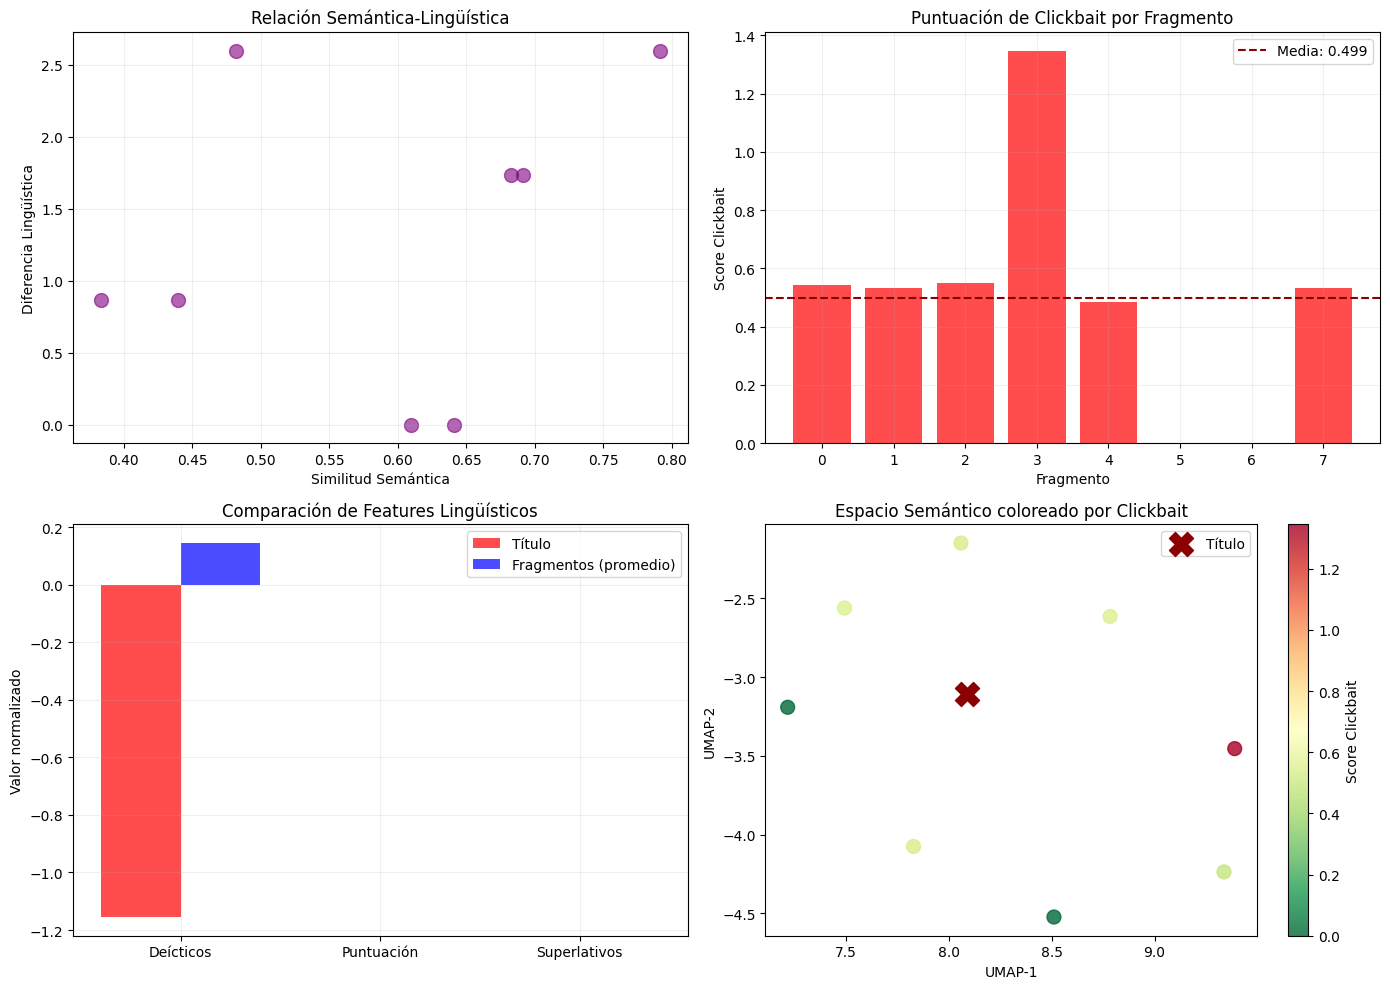

In [34]:
score, datos = analizar_clickbait(noticias, 6, plot=True)

### LSA

In [10]:
# corpus=cargar_datos(1)
similitudes,tfidf_lsa=LSA_vectors(corpus,min_df=2)


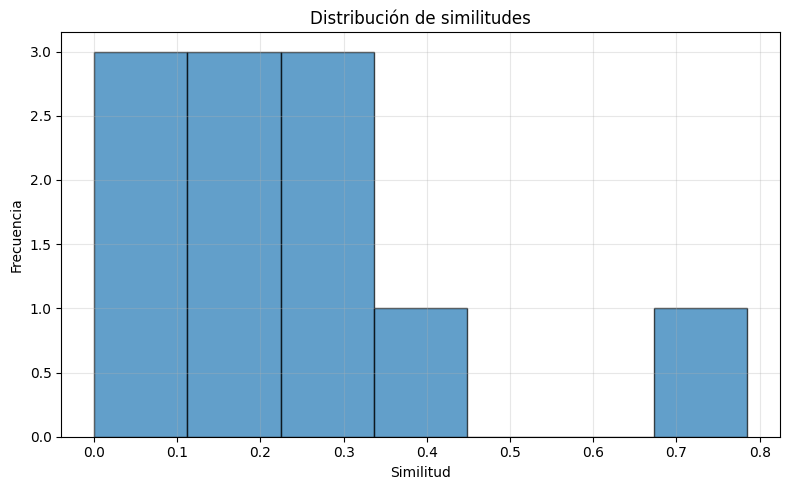

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    similitudes,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Embeding semántico

Aplicar:Crear un vector adicional de features de decticos, puntuación, superlativos. Si el embeding cae en una zona del espacio muy cargada de adjetivos pero el cuerpo está en una zona neutral, esa diferencia puede ser indicios de clickbait.

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


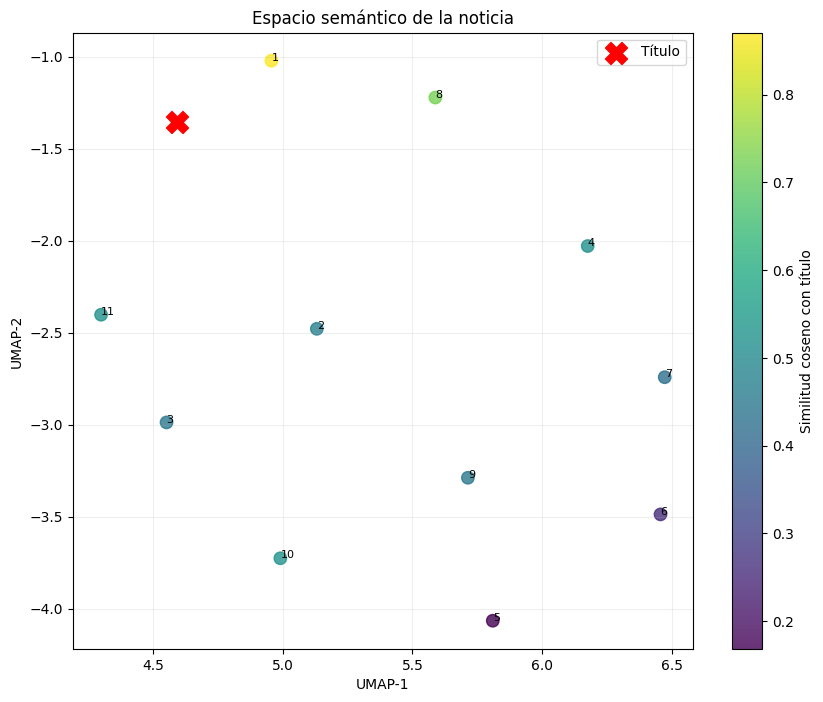

In [12]:
# corpus=cargar_datos(1)


similarities,embeddings=embedding_sentence_transformers(corpus)
embedding_2d=embedding_umap(similarities,embeddings, plot=True)

### Cross encoder

In [13]:
# corpus=cargar_datos(1)

probabilities = embedding_cross_encoder(corpus)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1593.63it/s]


In [14]:
probabilities

array([9.9990332e-01, 1.3110045e-01, 2.7596576e-05, 2.1976733e-03,
       1.2876525e-05, 1.7030254e-05, 3.5303498e-03, 7.2955912e-01,
       1.8634187e-01, 1.1990397e-01, 3.8818934e-04], dtype=float32)

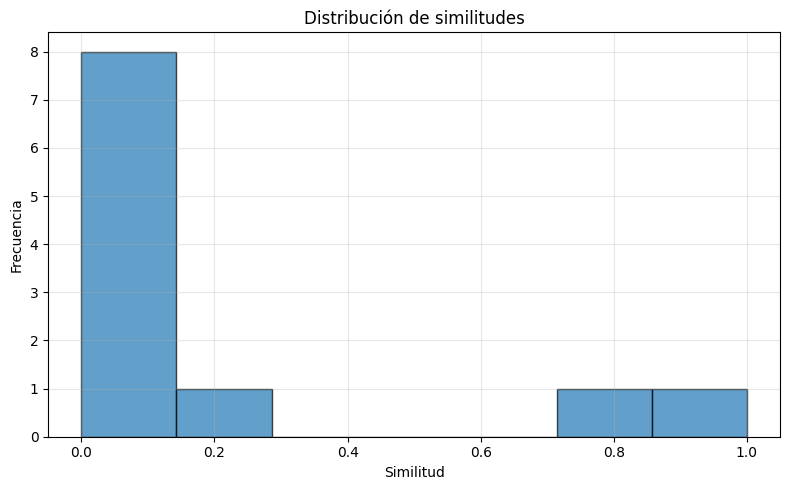

In [15]:



plt.figure(figsize=(8, 5))

plt.hist(
    probabilities,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**COSAS QUE HE IDO PROBANDO**

----

In [16]:
import numpy as np
import pandas as pd

# =========================
# Parámetros globales
# =========================

N_ARCHIVOS = 63 # ajusta a tu caso

resultados = []

# =========================
# Loop sobre noticias
# =========================

for i in range(N_ARCHIVOS):

    try:
        noticia, corpus = cargar_datos(i)
        categoria=noticia["Categoría"]
        periodico=noticia["Periódico"]
        similarities, embeddings = embedding_sentence_transformers(corpus)

        similarities = np.array(similarities)

        # =========================
        # Métricas básicas
        # =========================

        media = similarities.mean()
        std = similarities.std()
        minimo = similarities.min()
        maximo = similarities.max()

        # porcentaje de frases relevantes
        umbral = 0.6
        relevancia = np.mean(similarities > umbral)

        # entropía (versión simple con softmax)
        exp_sim = np.exp(similarities)
        probs = exp_sim / np.sum(exp_sim)

        entropia = -np.sum(probs * np.log(probs + 1e-12))

        resultados.append({
            "id": i,
            "categoría": categoria,
            "periódico": periodico,
            "media_sim": media,
            "std_sim": std,
            "min_sim": minimo,
            "max_sim": maximo,
            "ratio_relevante": relevancia,
            "entropia": entropia
        })

    except Exception as e:
        print(f"Error en archivo {i}: {e}")

# =========================
# DataFrame final
# =========================

df = pd.DataFrame(resultados)

print(df.head())

# =========================
# Estadísticas globales
# =========================

print("\nResumen global:")
print(df.describe())

Batches: 100%|██████████| 1/1 [00:00<00:00, 33.55it/s]

   id      categoría  periódico  media_sim   std_sim   min_sim   max_sim  \
0   0  Internacional  20minutos   0.766291  0.044968  0.721323  0.811259   
1   1  Internacional  20minutos   0.443021  0.124735  0.262950  0.675514   
2   2  Internacional  20minutos   0.448650  0.182501  0.288300  0.703970   
3   3       Nacional  20minutos   0.477700  0.118087  0.210933  0.666458   
4   4       Nacional  20minutos   0.547311  0.182992  0.376594  0.918128   

   ratio_relevante  entropia  
0         1.000000  0.692137  
1         0.192308  3.250077  
2         0.333333  1.080901  
3         0.200000  2.701162  
4         0.375000  2.061020  

Resumen global:
              id  media_sim    std_sim    min_sim    max_sim  ratio_relevante  \
count  63.000000  63.000000  63.000000  63.000000  63.000000        63.000000   
mean   31.000000   0.461090   0.150547   0.226746   0.745232         0.231510   
std    18.330303   0.106537   0.067968   0.182746   0.109271         0.258913   
min     0.000000

In [17]:
df

,id,categoría,periódico,media_sim,std_sim,min_sim,max_sim,ratio_relevante,entropia
0,0,Internacional,20minutos,0.766291,0.044968,0.721323,0.811259,1.000000,0.692137
1,1,Internacional,20minutos,0.443021,0.124735,0.262950,0.675514,0.192308,3.250077
2,2,Internacional,20minutos,0.448650,0.182501,0.288300,0.703970,0.333333,1.080901
3,3,Nacional,20minutos,0.477700,0.118087,0.210933,0.666458,0.200000,2.701162
4,4,Nacional,20minutos,0.547311,0.182992,0.376594,0.918128,0.375000,2.061020
...,...,...,...,...,...,...,...,...,...
58,58,Nacional,RTVE,0.558173,0.124761,0.433412,0.682933,0.500000,0.685425
59,59,Nacional,RTVE,0.335473,0.171560,0.176686,0.724698,0.125000,2.062498
60,60,Cultura,RTVE,0.511739,0.014208,0.497531,0.525948,0.000000,0.693046
61,61,Cultura,RTVE,0.538437,0.042570,0.492995,0.595357,0.000000,1.097697


<Axes: >

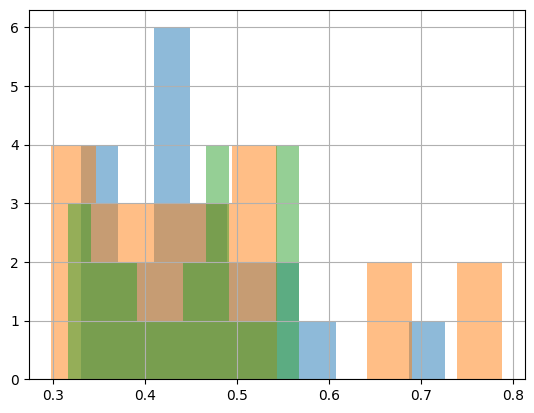

In [18]:
# df["media_sim"].hist()
df[df["categoría"]=="Cultura"]["media_sim"].hist(alpha=0.5, label="Cultura")
df[df["categoría"]=="Internacional"]["media_sim"].hist(alpha=0.5, label="Internacional")
df[df["categoría"]=="Nacional"]["media_sim"].hist(alpha=0.5, label="Nacional")

<Axes: >

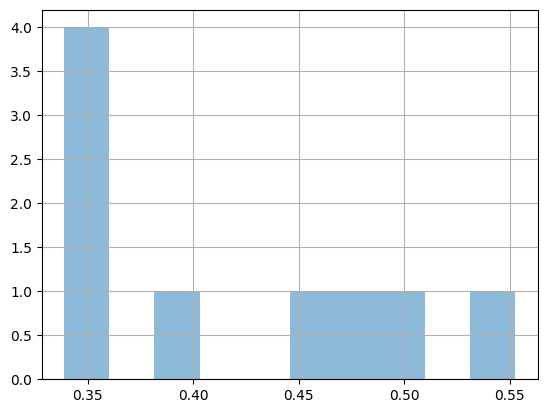

In [19]:
# df[df["periódico"]=="20minutos"]["media_sim"].hist(alpha=0.5, label="Cultura")
df[df["periódico"]=="okdiario"]["media_sim"].hist(alpha=0.5, label="Cultura")
# df[df["periódico"]=="RTVE"]["media_sim"].hist(alpha=0.5, label="Cultura")





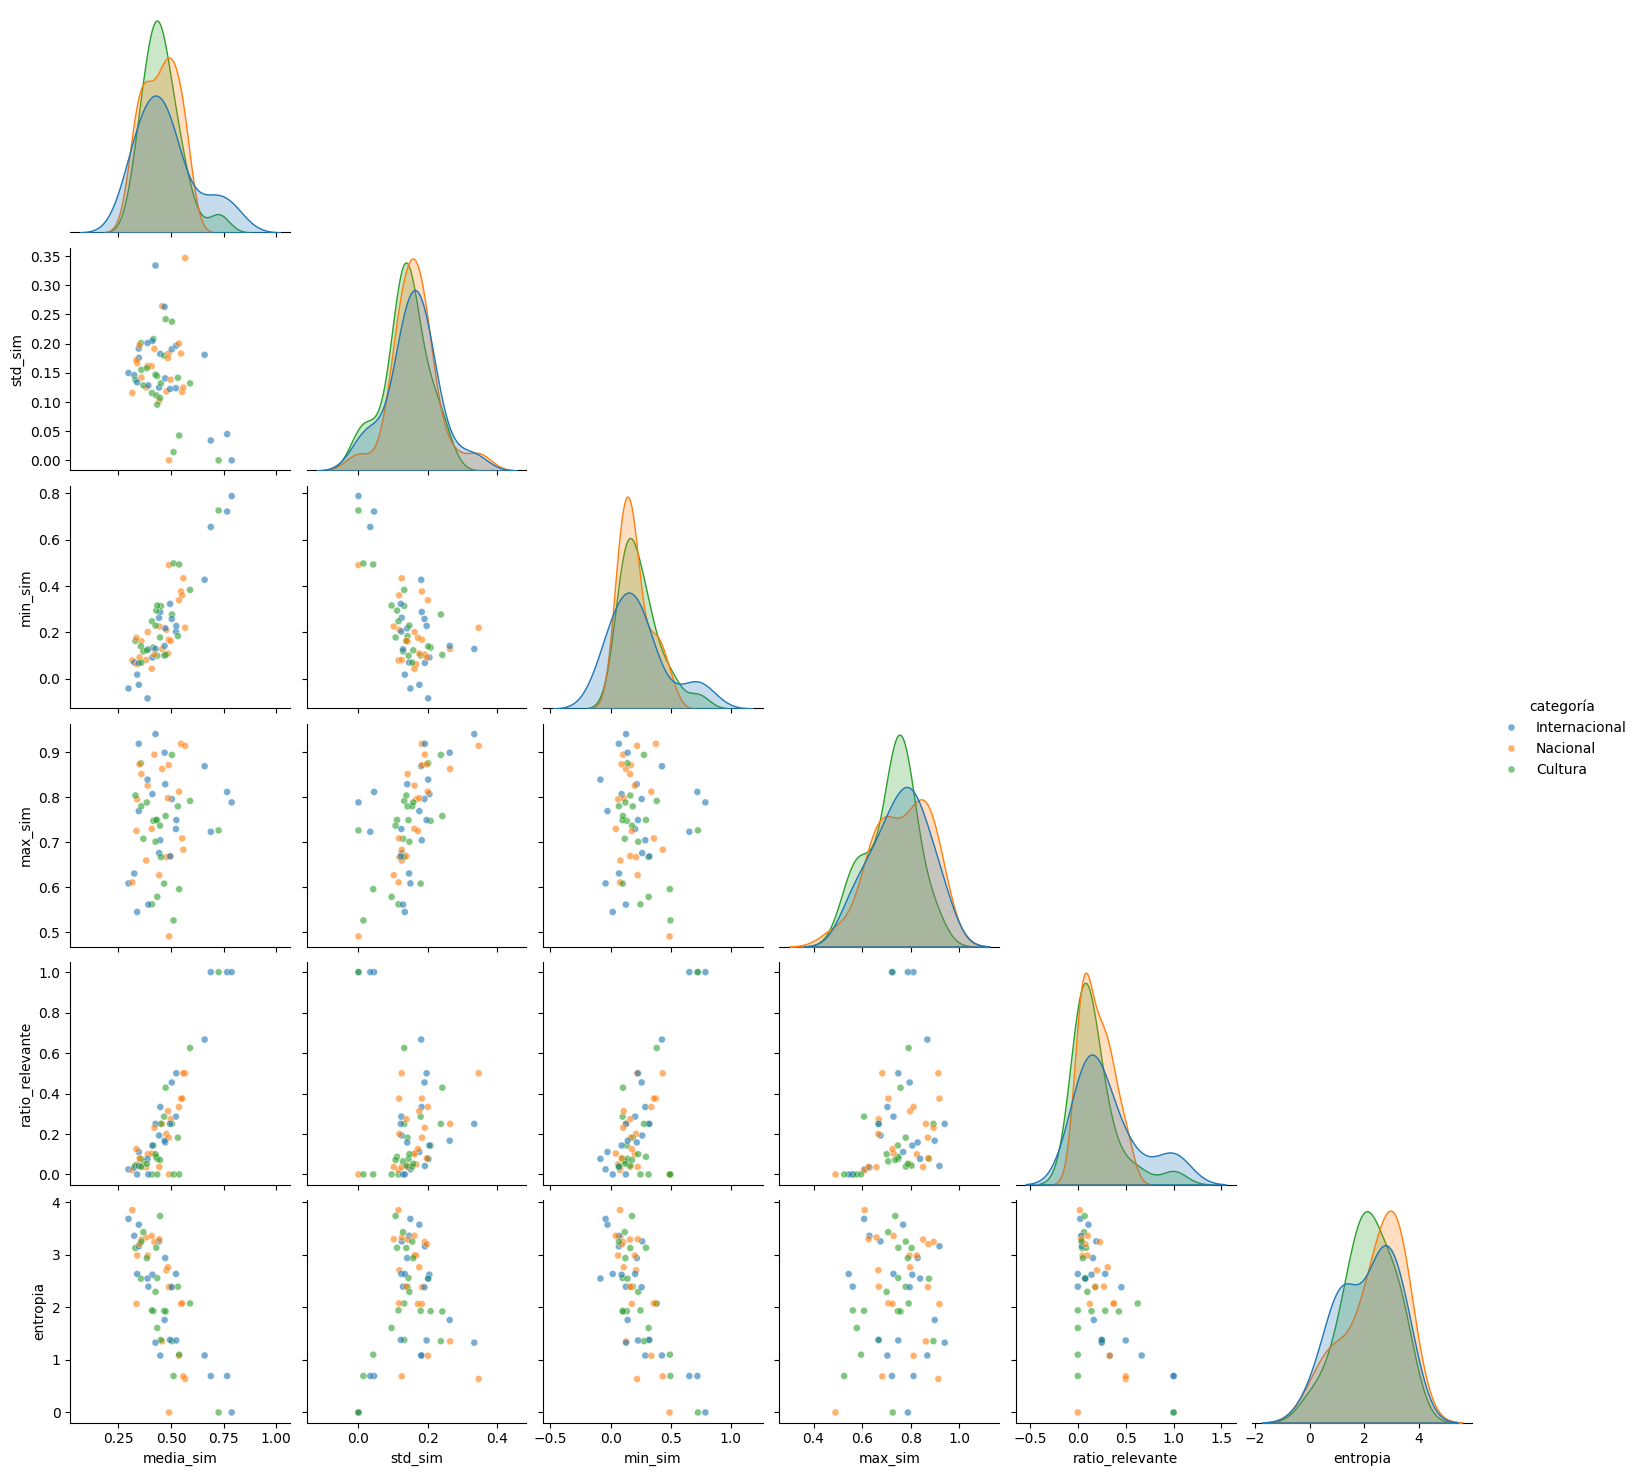

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Selección de variables
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

# =========================
# Pairplot
# =========================

sns.pairplot(
    df[cols + ["categoría"]],
    hue="categoría",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.show()

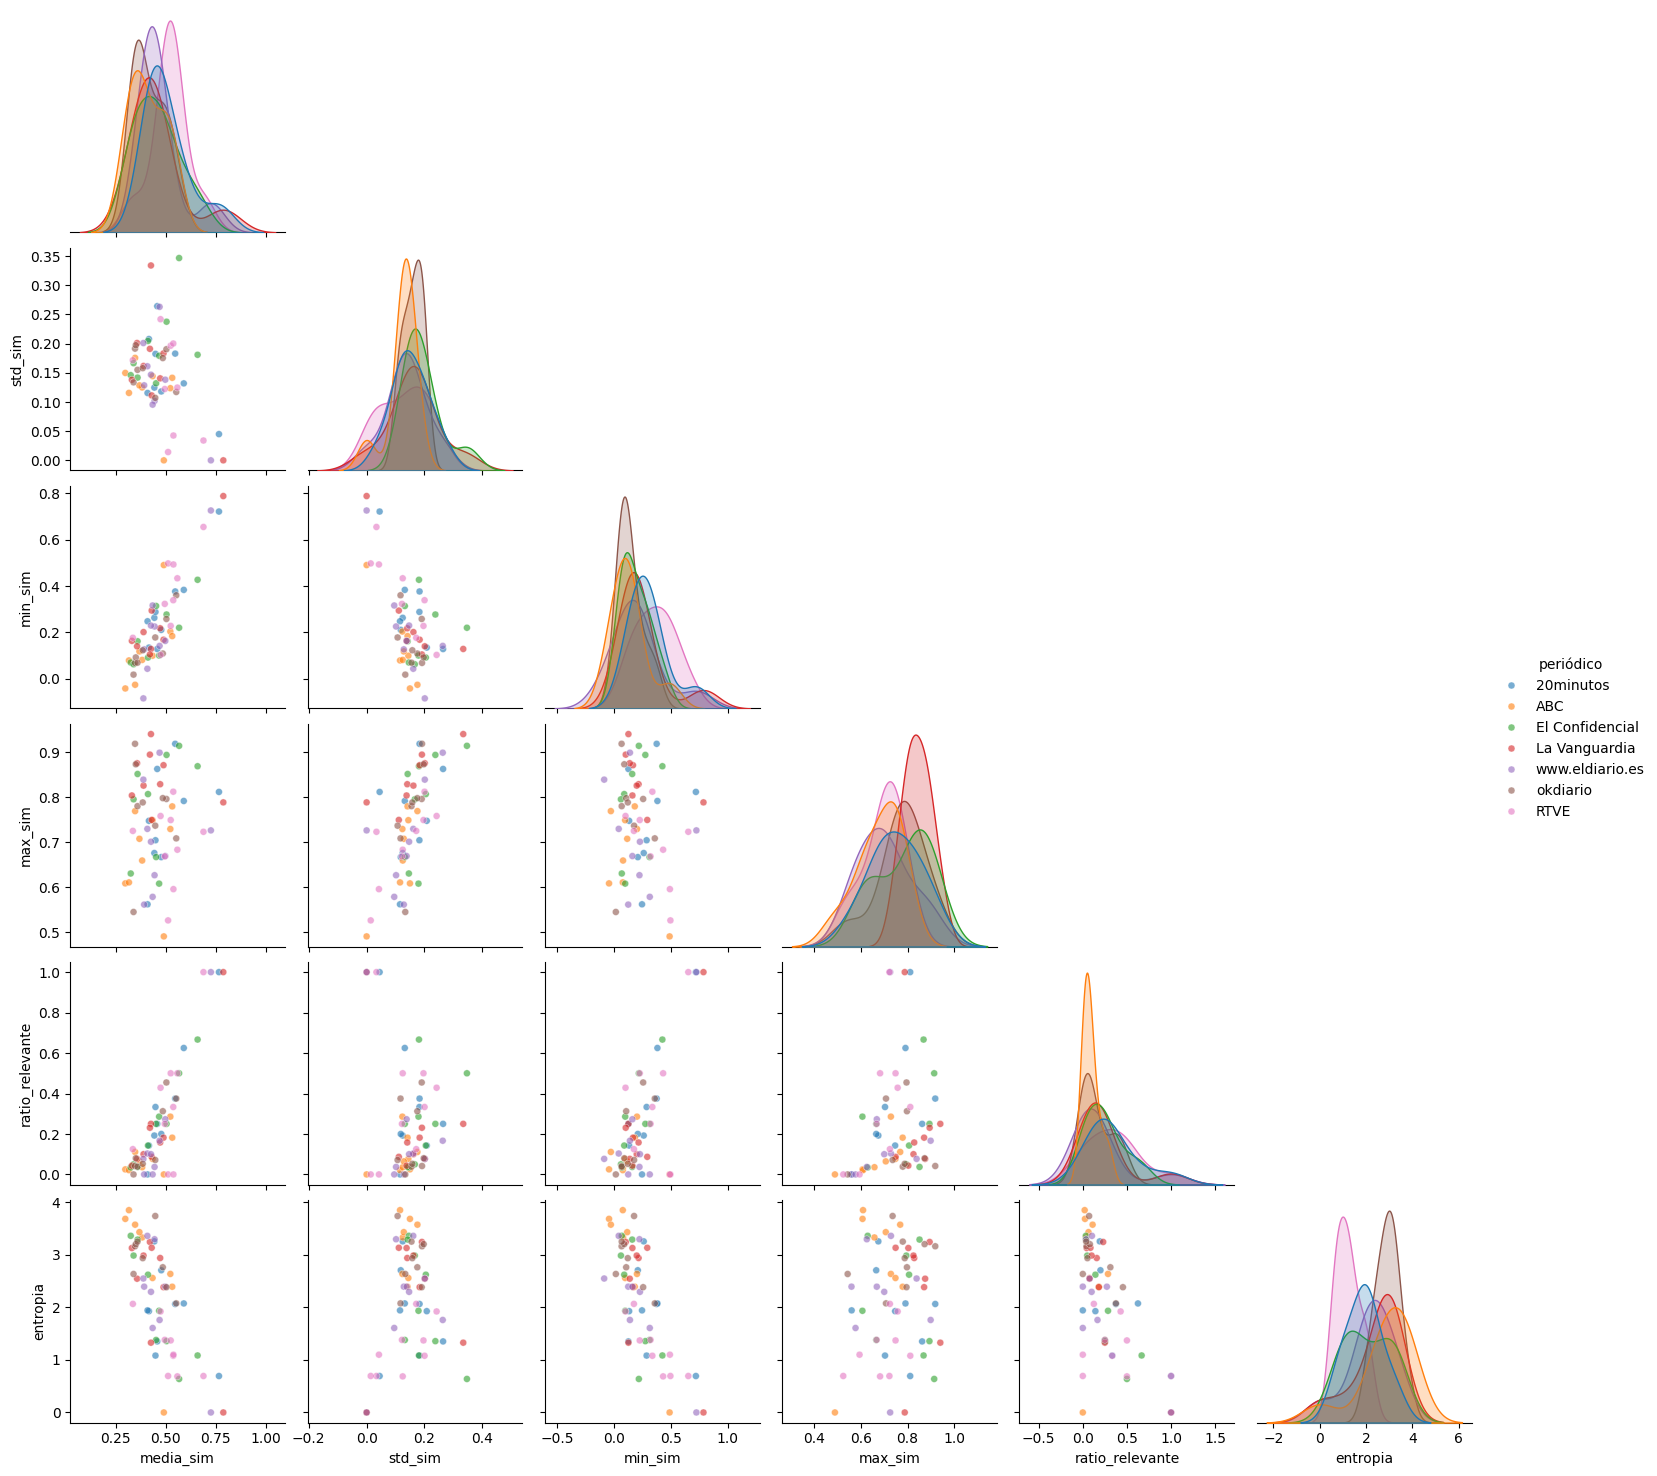

In [21]:
cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

# =========================
# Pairplot
# =========================

sns.pairplot(
    df[cols + ["periódico"]],
    hue="periódico",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.show()

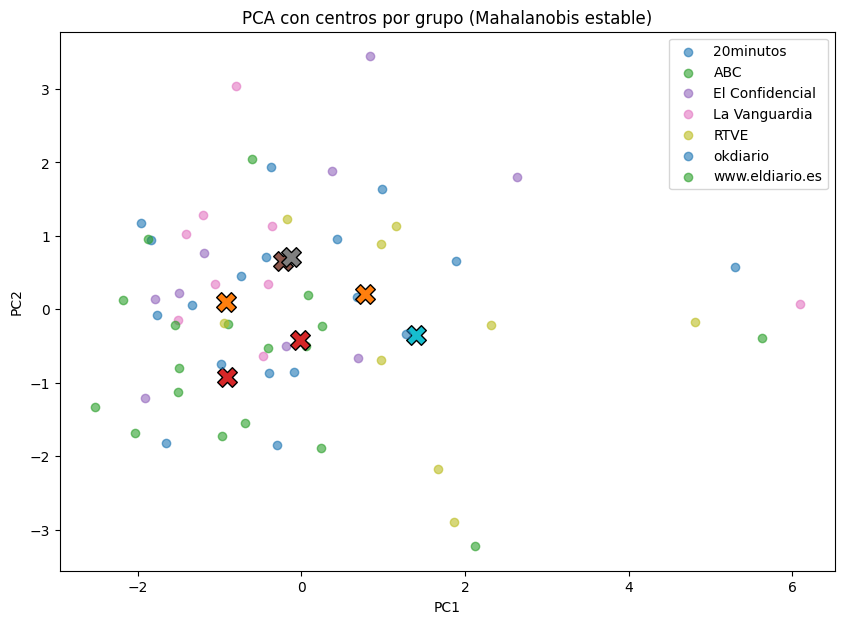

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis

# =========================
# Features
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

X = df[cols].dropna()
y = df.loc[X.index, "periódico"]

# =========================
# Escalado + PCA
# =========================

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["grupo"] = y.values

# =========================
# Covarianza GLOBAL (clave para evitar errores)
# =========================

cov_global = np.cov(X_pca.T)
inv_cov_global = np.linalg.pinv(cov_global)

# =========================
# Centros por grupo
# =========================

centros = df_pca.groupby("grupo")[["PC1", "PC2"]].mean()

# =========================
# Distancias Mahalanobis
# =========================

df_pca["mahalanobis"] = np.nan

for grupo in centros.index:

    subset_idx = df_pca["grupo"] == grupo
    subset = df_pca.loc[subset_idx, ["PC1", "PC2"]].values

    centro = centros.loc[grupo].values

    for i, x in zip(df_pca[subset_idx].index, subset):

        d = mahalanobis(x, centro, inv_cov_global)
        df_pca.loc[i, "mahalanobis"] = d

# =========================
# Plot
# =========================

plt.figure(figsize=(10, 7))

for grupo in centros.index:

    subset = df_pca[df_pca["grupo"] == grupo]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=grupo
    )

    plt.scatter(
        centros.loc[grupo, "PC1"],
        centros.loc[grupo, "PC2"],
        s=200,
        marker="X",
        edgecolor="black"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA con centros por grupo (Mahalanobis estable)")
plt.legend()
plt.show()

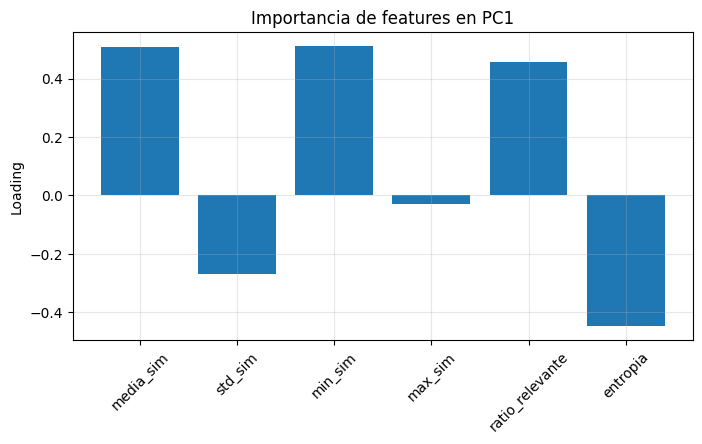

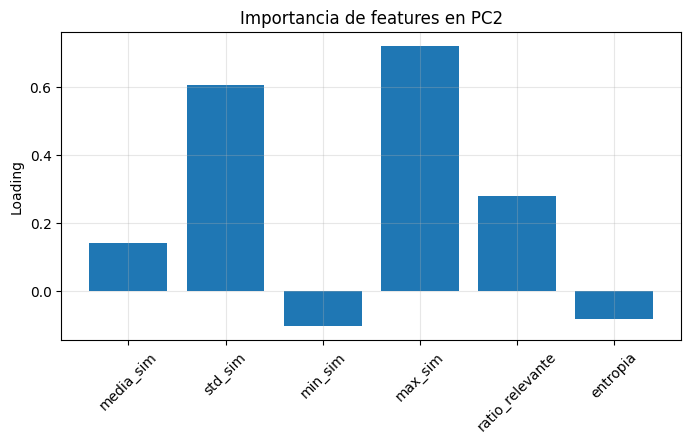

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# =========================
# Features
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

X = df[cols].dropna()

# Escalado
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=["PC1", "PC2"]
)

# =========================
# Plot PC1
# =========================

plt.figure(figsize=(8, 4))
plt.bar(loadings.index, loadings["PC1"])
plt.xticks(rotation=45)
plt.title("Importancia de features en PC1")
plt.ylabel("Loading")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Plot PC2
# =========================

plt.figure(figsize=(8, 4))
plt.bar(loadings.index, loadings["PC2"])
plt.xticks(rotation=45)
plt.title("Importancia de features en PC2")
plt.ylabel("Loading")
plt.grid(alpha=0.3)
plt.show()

### Question Answering (QA)

Convertir el titular en una pregunta con un transformers de QA y ver si encuentra la respuesta en qué frase del texto, si es al final del texto o no aparece puede dar indicios de clickbait



### Buscar si el cuerpo aporta más información (entropía)

Hipótesis: El contenido en noticias con clickbait tienen una tasa de redundancia muy alta. Dice mucho en el título y casi nada de información nueva en el contenido (entropía baja)